In [2]:
import pandas as pd

df_main = pd.read_csv("/content/detections.csv")        # person + racket
df_ball = pd.read_csv("/content/ball_detections.csv")   # ball

# --- Fix column name mismatch ---
df_ball = df_ball.rename(columns={"conf": "confidence"})

# --- Ensure expected columns exist in main ---
cols_main = ["frame", "track_id", "label", "x1", "y1", "x2", "y2", "confidence"]
df_main = df_main[cols_main]

# --- Build ball dataframe in same schema ---
df_ball = df_ball[["frame", "x1", "y1", "x2", "y2", "confidence"]].copy()

# Add missing columns for compatibility
df_ball["track_id"] = -1          # or any sentinel value
df_ball["label"] = "ball"

# --- OPTIONAL: make track IDs unique ---
df_ball["track_id"] = df_ball["track_id"]+1000  # avoids clashes

# --- tag source ---
df_main["source"] = "main"
df_ball["source"] = "ball"

# Merge
df_all = pd.concat([df_main, df_ball], ignore_index=True)

# Sort
df_all = df_all.sort_values(["frame"]).reset_index(drop=True)

# --- center coordinates ---
df_all["cx"] = (df_all["x1"] + df_all["x2"]) / 2
df_all["cy"] = (df_all["y1"] + df_all["y2"]) / 2

df_all["cx"] = df_all["cx"].round(2)
df_all["cy"] = df_all["cy"].round(2)

df_all.to_csv("combined_detections.csv", index=False)

print("Saved → combined_detections.csv")

Saved → combined_detections.csv


In [3]:
import cv2
import pandas as pd

df = pd.read_csv("combined_detections.csv")

colors = {
    "person": (0, 255, 0),
    "racket": (255, 0, 0),
    "ball": (0, 0, 255)
}

frame_group = df.groupby("frame")

cap = cv2.VideoCapture("input.mp4")

fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(
    "output.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (w, h)
)

frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_idx in frame_group.groups:
        for _, row in frame_group.get_group(frame_idx).iterrows():
            x1, y1, x2, y2 = map(int, [row.x1, row.y1, row.x2, row.y2])
            label = row.label

            color = colors.get(label, (255, 255, 255))

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(frame,
                        f"{label} {row.track_id}",
                        (x1, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        color,
                        1)

    out.write(frame)
    frame_idx += 1

cap.release()
out.release()

print("Done → output.mp4")

Done → output.mp4


In [6]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105580 entries, 0 to 105579
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   frame       105580 non-null  int64  
 1   track_id    105580 non-null  int64  
 2   label       105580 non-null  object 
 3   x1          105580 non-null  int64  
 4   y1          105580 non-null  int64  
 5   x2          105580 non-null  int64  
 6   y2          105580 non-null  int64  
 7   confidence  105580 non-null  float64
 8   source      105580 non-null  object 
 9   cx          105580 non-null  float64
 10  cy          105580 non-null  float64
dtypes: float64(3), int64(6), object(2)
memory usage: 8.9+ MB


In [68]:
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

MINIMUM_DISTANCE_THRESHOLD = 150

def compute_windowed_racket_ball_distance_fast(df, window=5):
    balls_df = df[df["label"] == "ball"][["frame", "track_id", "cx", "cy"]].copy()
    rackets_df = df[df["label"] == "racket"][["frame", "track_id", "cx", "cy"]].copy()

    # expand ball frames to cover window range
    offsets = np.arange(-window, window + 1)

    # cross join each ball frame with offsets -> gives "search frames"
    balls_df = balls_df.assign(key=1)
    offset_df = pd.DataFrame({"offset": offsets, "key": 1})

    balls_expanded = balls_df.merge(offset_df, on="key").drop("key", axis=1)
    balls_expanded["search_frame"] = balls_expanded["frame"] + balls_expanded["offset"]

    # merge rackets on search_frame
    merged = balls_expanded.merge(
        rackets_df.rename(columns={"frame": "search_frame", "track_id": "racket_id", "cx": "rcx", "cy": "rcy"}),
        on="search_frame"
    )

    if merged.empty:
        return pd.DataFrame(columns=["frame", "racket_id", "track_id", "distance"])

    # vectorized distance
    merged["distance"] = np.sqrt(
        (merged["cx"] - merged["rcx"]) ** 2 +
        (merged["cy"] - merged["rcy"]) ** 2
    )

    # filter threshold
    merged = merged[merged["distance"] <= MINIMUM_DISTANCE_THRESHOLD]

    if merged.empty:
        return pd.DataFrame(columns=["frame", "racket_id", "track_id", "distance"])

    # per ball-frame, keep closest racket
    idx = merged.groupby(["frame", "track_id"])["distance"].idxmin()
    result = merged.loc[idx, ["frame", "racket_id", "track_id", "distance"]].reset_index(drop=True)

    return result

In [69]:
df_dist = compute_windowed_racket_ball_distance_fast(df_all, window=5)
print(df_dist)

      frame  racket_id  track_id    distance
0        11          8       999   88.865066
1        13          8       999   92.920665
2        14          8       999   96.798760
3        15          8       999  103.885755
4        16          8       999  112.767460
...     ...        ...       ...         ...
3162   8096      10512       999    6.000000
3163   8113      10512       999  116.722963
3164   8114      10512       999  125.092965
3165   8115      10512       999  136.118515
3166   8116      10512       999  146.480374

[3167 rows x 4 columns]


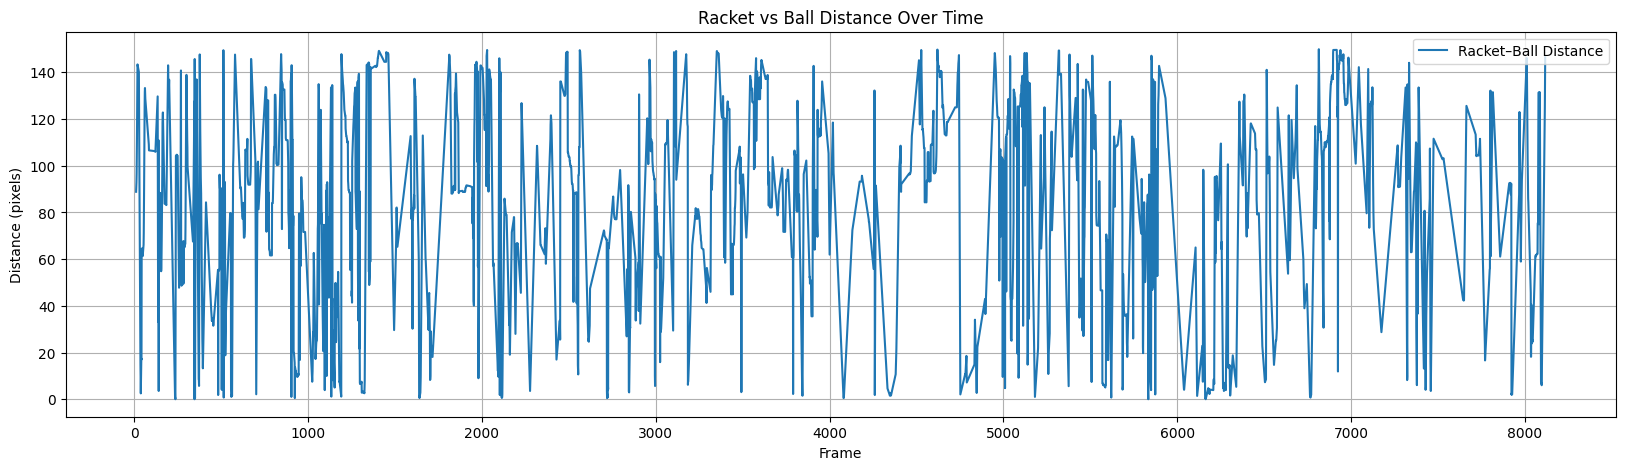

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,5))
plt.plot(df_dist["frame"], df_dist["distance"], label="Racket–Ball Distance")

plt.xlabel("Frame")
plt.ylabel("Distance (pixels)")
plt.title("Racket vs Ball Distance Over Time")
plt.legend()
plt.grid()

plt.show()

In [71]:
import numpy as np
from scipy.signal import argrelextrema

# 1. Identify the indices of the dips
# order=15 ensures we find the major 'hits' and ignore small tracking jitters
dip_indices = argrelextrema(df_dist['distance'].values, np.less_equal, order=3)[0]

# 2. Extract the actual frames and distances
local_minima = df_dist.iloc[dip_indices].copy()

# 3. Clean up: If a dip is a plateau (multiple frames with same value),
# keep only the middle frame of that hit.
local_minima = local_minima.groupby('distance').head(1)
local_minima

,frame,racket_id,track_id,distance
0,11,8,999,88.865066
19,38,35,999,2.500000
28,49,45,999,61.320877
50,141,167,999,3.535534
64,155,190,999,54.829280
...,...,...,...,...
3112,7976,10354,999,58.961852
3131,8034,10457,999,18.200275
3140,8043,10452,999,24.520400
3151,8071,10486,999,62.261545


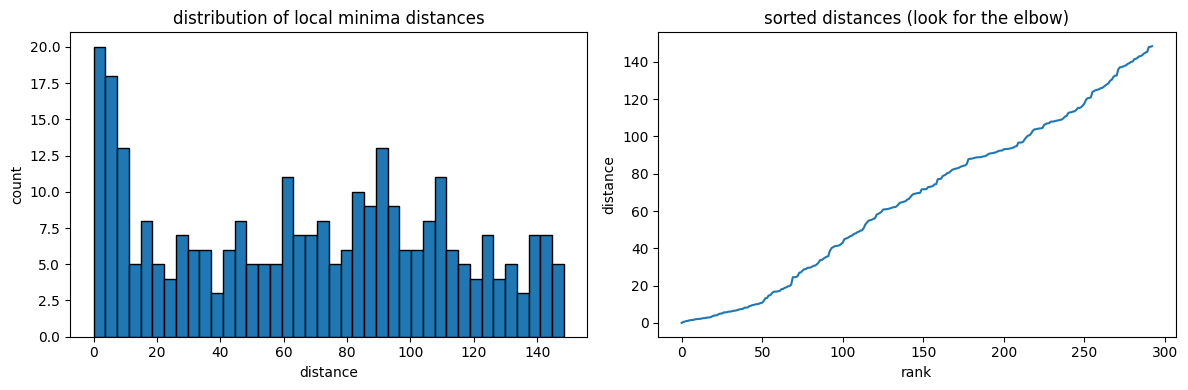

In [72]:
# visualize the distribution to determine the cutoff
import matplotlib.pyplot as plt

distances = local_minima['distance'].values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# histogram
axes[0].hist(distances, bins=40, edgecolor='black')
axes[0].set_xlabel('distance')
axes[0].set_ylabel('count')
axes[0].set_title('distribution of local minima distances')

# sorted plot - clearest for finding a cutoff
axes[1].plot(sorted(distances))
axes[1].set_xlabel('rank')
axes[1].set_ylabel('distance')
axes[1].set_title('sorted distances (look for the elbow)')

plt.tight_layout()
plt.show()

In [73]:
distance_threshold = 100
racket_hits = local_minima[local_minima["distance"] < distance_threshold]
print(racket_hits)

      frame  racket_id  track_id   distance
0        11          8       999  88.865066
19       38         35       999   2.500000
28       49         45       999  61.320877
50      141        167       999   3.535534
64      155        190       999  54.829280
...     ...        ...       ...        ...
3112   7976      10354       999  58.961852
3131   8034      10457       999  18.200275
3140   8043      10452       999  24.520400
3151   8071      10486       999  62.261545
3162   8096      10512       999   6.000000

[215 rows x 4 columns]


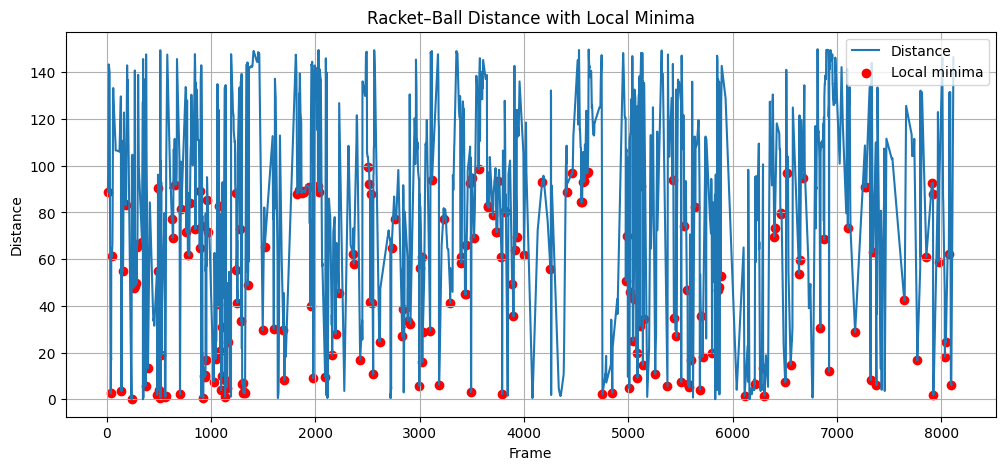

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df_dist["frame"], df_dist["distance"], label="Distance")

plt.scatter(
    racket_hits["frame"],
    racket_hits["distance"],
    color="red",
    label="Local minima"
)

plt.xlabel("Frame")
plt.ylabel("Distance")
plt.title("Racket–Ball Distance with Local Minima")
plt.legend()
plt.grid()
plt.show()

In [75]:
import numpy as np

def dist(a, b):
    return np.sqrt((a["cx"] - b["cx"])**2 + (a["cy"] - b["cy"])**2)

In [76]:
# Expand hit frames by ±3
expanded_frames = set()

# racket-ball hit bhayeko frame ko suruma 3 frame pachi samma ra suruma 3 frame aghi samma lai include garne
for f in racket_hits["frame"]:
    for offset in range(-3, 4):   # -3 to +3 inclusive
        expanded_frames.add(f + offset)

# Filter dataframe
df_players_rackets_hits = df_all[
    (df_all["frame"].isin(expanded_frames)) &
    (df_all["label"].isin(["person", "racket"]))
].copy()

print(df_players_rackets_hits)

        frame  track_id   label    x1   y1    x2   y2  confidence source  \
103         8         2  person   786   52   831  133    0.849946   main   
104         8         9  person   608  658   754  846    0.780482   main   
105         8         6  person   141  218   196  292    0.773447   main   
106         8         1  person  1201  282  1278  439    0.883261   main   
107         8         7  person   860    4   886   58    0.751821   main   
...       ...       ...     ...   ...  ...   ...  ...         ...    ...   
105212   8099     10108  racket   754  352   795  377    0.810676   main   
105213   8099      9648  person   989   15  1021   74    0.820542   main   
105214   8099     10492  person   440  129   480  225    0.557456   main   
105215   8099     10467  person  1081   35  1116   98    0.834733   main   
105216   8099     10488  person    64  423   108  476    0.351002   main   

            cx     cy  
103      808.5   92.5  
104      681.0  752.0  
105      168.5 

In [77]:
import numpy as np
import pandas as pd

results = []

for frame in df_players_rackets_hits["frame"].unique():

    frame_df = df_players_rackets_hits[
        df_players_rackets_hits["frame"] == frame
    ]

    # racket + ball ids for this frame
    racket_hit_row = racket_hits[
        racket_hits["frame"] == frame
    ]

    if racket_hit_row.empty:
        continue

    racket_id = racket_hit_row.iloc[0]["racket_id"]

    # select ONLY that racket
    racket = frame_df[
        (frame_df["label"] == "racket") &
        (frame_df["track_id"] == racket_id)
    ]

    players = frame_df[
        frame_df["label"] == "person"
    ]

    if racket.empty or players.empty:
        continue

    rx, ry = racket.iloc[0]["cx"], racket.iloc[0]["cy"]

    for _, p in players.iterrows():

        dist = np.sqrt(
            (rx - p["cx"])**2 +
            (ry - p["cy"])**2
        )

        results.append({
            "frame": frame,
            "racket_id": racket_id,
            "player_id": p["track_id"],
            "distance": dist
        })

df_dist_person_racket = pd.DataFrame(results)

print(df_dist_person_racket)

     frame  racket_id  player_id    distance
0       11        8.0          3  734.961564
1       11        8.0          9   62.032250
2       11        8.0          1  634.425133
3       11        8.0          2  642.341420
4       11        8.0          7  710.272659
..     ...        ...        ...         ...
769   8096    10512.0       9503  487.252758
770   8096    10512.0      10492  752.496013
771   8096    10512.0      10488  841.209249
772   8096    10512.0      10082  771.608223
773   8096    10512.0       8149  720.529319

[774 rows x 4 columns]


In [78]:
# map: (frame, closest_player)
frame_player_map = df_dist_person_racket.groupby("frame").apply(
    lambda x: x.loc[x["distance"].idxmin(), "player_id"]
).to_dict()
frame_player_map

/tmp/ipykernel_648/1320283732.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  frame_player_map = df_dist_person_racket.groupby("frame").apply(


{11: 9,
 237: 2,
 258: 7,
 289: 2,
 373: 9,
 515: 2,
 563: 2,
 631: 1,
 657: 1,
 715: 3,
 782: 1,
 796: 1,
 913: 928,
 924: 3,
 932: 928,
 973: 5,
 1138: 5,
 1153: 1,
 1237: 1301,
 1243: 1,
 1253: 5,
 1280: 1,
 1303: 1,
 1316: 1828,
 1324: 1828,
 1352: 1301,
 1825: 2371,
 1886: 2371,
 1890: 2371,
 1940: 2371,
 2094: 1301,
 2368: 2371,
 2509: 3018,
 2526: 3018,
 2531: 3018,
 2730: 3018,
 2767: 3018,
 2996: 3919,
 3003: 3919,
 3018: 3018,
 3029: 3919,
 3118: 3018,
 3393: 1301,
 3399: 1301,
 3447: 4357,
 3492: 1301,
 3499: 3349,
 3521: 3018,
 3565: 1301,
 3650: 1301,
 3657: 4357,
 3701: 4357,
 3734: 4357,
 3739: 4357,
 3754: 1301,
 3790: 4036,
 3814: 4036,
 3821: 4036,
 3898: 4036,
 3914: 4036,
 3930: 4036,
 4000: 3919,
 4176: 3018,
 4464: 3018,
 4609: 3018,
 4752: 1301,
 4976: 6399,
 5051: 6399,
 5079: 6318,
 5113: 6245,
 5124: 6245,
 5258: 6318,
 5375: 6899,
 5424: 6245,
 5437: 6899,
 5559: 6899,
 5641: 6318,
 5697: 7046,
 6114: 1301,
 6212: 7774,
 6295: 7046,
 6399: 8149,
 6464: 7774,


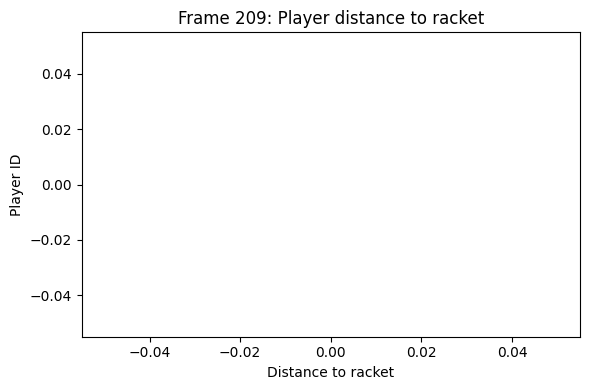

In [66]:
import matplotlib.pyplot as plt

frame_id = 209
df_f = df_dist_person_racket[df_dist_person_racket["frame"] == frame_id] \
        .sort_values("distance")

plt.figure(figsize=(6,4))
plt.barh(df_f["player_id"].astype(str), df_f["distance"])
plt.xlabel("Distance to racket")
plt.ylabel("Player ID")
plt.title(f"Frame {frame_id}: Player distance to racket")
plt.tight_layout()
plt.show()

In [79]:

df_main = pd.read_csv("/content/combined_detections.csv")
filtered_rows = []

for _, row in df_dist_person_racket.iterrows():

    frame = row["frame"]
    racket_id = row["racket_id"]

    # ONLY use closest player for this frame
    player_id = frame_player_map[frame]

    keep = df_main[
        (df_main["frame"] == frame) &
        (
            ((df_main["label"] == "person") & (df_main["track_id"] == player_id)) |
            ((df_main["label"] == "racket") & (df_main["track_id"] == racket_id)) |
            (df_main["label"] == "ball")
        )
    ]

    filtered_rows.append(keep)

df_filtered = pd.concat(filtered_rows, ignore_index=True)

# optional: remove duplicates
df_filtered = df_filtered.drop_duplicates()

df_filtered

,frame,track_id,label,x1,y1,x2,y2,confidence,source,cx,cy
0,11,9,person,590,655,744,845,0.898352,main,667.0,750.0
1,11,999,ball,1023,272,1032,281,0.372083,ball,1027.5,276.5
2,11,999,ball,634,669,652,684,0.175487,ball,643.0,676.5
3,11,999,ball,5,574,14,582,0.280109,ball,9.5,578.0
4,11,8,racket,698,703,752,753,0.782513,main,725.0,728.0
...,...,...,...,...,...,...,...,...,...,...,...
4482,8096,10512,racket,810,815,866,838,0.499102,main,838.0,826.5
4483,8096,999,ball,837,820,853,830,0.125954,ball,845.0,825.0
4484,8096,999,ball,5,574,14,582,0.271399,ball,9.5,578.0
4485,8096,999,ball,1114,290,1124,298,0.612529,ball,1119.0,294.0


In [80]:
cap = cv2.VideoCapture("input.mp4")

frame_idx = 0
results = {}

colors = {
    "person": (0, 255, 0),
    "racket": (255, 0, 0),
    "ball": (0, 0, 255)
}

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_idx in df_filtered["frame"].values:

        group = df_filtered[df_filtered["frame"] == frame_idx]

        for _, row in group.iterrows():

            x1, y1, x2, y2 = map(int, [row.x1, row.y1, row.x2, row.y2])
            color = colors[row.label]

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

            cv2.putText(
                frame,
                f"{row.label} {row.track_id}",
                (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                color,
                2
            )

        results[frame_idx] = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    frame_idx += 1

cap.release()


import math
# 1. Get the list of frames you want to show
frames_to_show = df_filtered["frame"].unique()
num_frames = len(frames_to_show)

# 2. Calculate grid size (e.g., if 6 frames, do 2 rows of 3)
cols = 2
rows = math.ceil(num_frames / cols)

# 3. Create the figure
plt.figure(figsize=(15, 5 * rows))

for i, f in enumerate(frames_to_show):
    # If the frame was actually captured in your results dictionary
    if f in results:
        plt.subplot(rows, cols, i + 1)
        plt.imshow(results[f])
        plt.title(f"Frame {f} - Local Dip")
        plt.axis("off")

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [81]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 554 entries, 0 to 4486
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   frame       554 non-null    int64  
 1   track_id    554 non-null    int64  
 2   label       554 non-null    object 
 3   x1          554 non-null    int64  
 4   y1          554 non-null    int64  
 5   x2          554 non-null    int64  
 6   y2          554 non-null    int64  
 7   confidence  554 non-null    float64
 8   source      554 non-null    object 
 9   cx          554 non-null    float64
 10  cy          554 non-null    float64
dtypes: float64(3), int64(6), object(2)
memory usage: 51.9+ KB


In [82]:
results = []

x_thresh = 20
y_thresh = 15

for frame, group in df_filtered.groupby("frame"):

    person = group[group["label"] == "person"].iloc[0]
    racket = group[group["label"] == "racket"].iloc[0]

    cx_p, cy_p = person["cx"], person["cy"]
    cx_r, cy_r = racket["cx"], racket["cy"]

    dx = cx_r - cx_p
    dy = cy_r - cy_p

    # annotation- levl threshold filter
    if abs(dx) < x_thresh and abs(dy) < y_thresh:
        shot = "neutral"
    else:
        if cy_r < cy_p - y_thresh:
            shot = "serve"
        elif dx > x_thresh:
            shot = "forward shot"
        elif dx < -x_thresh:
            shot = "back shot"
        else:
            shot = "neutral"

    temp = group.copy()
    temp["result"] = shot
    temp["distance_pr"] = np.sqrt(dx**2 + dy**2)

    results.append(temp)

df_out = pd.concat(results, ignore_index=True)

# drop racket rows
df_out = df_out[df_out["label"] != "racket"].copy()
df_out = df_out[df_out["label"] != "ball"].copy()

df_out = df_out[["frame", "track_id", "label", "result", "distance_pr"]]

df_out.to_csv("output_with_shot.csv", index=False)

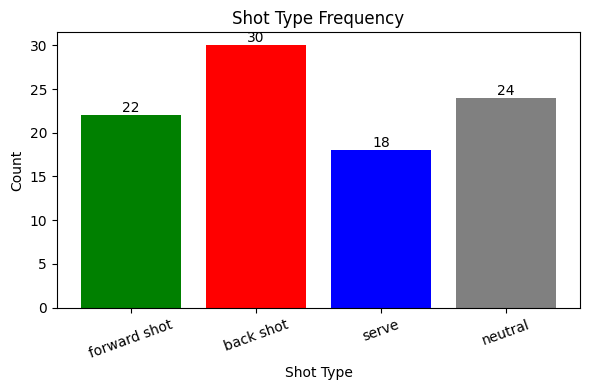

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("output_with_shot.csv")

all_shots = ["forward shot", "back shot", "serve", "neutral"]

counts = df["result"].value_counts().reindex(all_shots, fill_value=0)

colors = {
    "forward shot": "green",
    "back shot": "red",
    "serve": "blue",
    "neutral": "gray"
}

plt.figure(figsize=(6,4))

bars = plt.bar(
    counts.index,
    counts.values,
    color=[colors[k] for k in counts.index]
)

# add count labels
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        str(int(y)),
        ha='center',
        va='bottom'
    )

plt.title("Shot Type Frequency")
plt.xlabel("Shot Type")
plt.ylabel("Count")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [84]:
df_det = pd.read_csv("combined_detections.csv")
df_events = pd.read_csv("output_with_shot.csv")
df_events

,frame,track_id,label,result,distance_pr
0,11,9,person,serve,62.032250
1,237,2,person,forward shot,28.460499
2,258,7,person,forward shot,21.224985
3,289,2,person,back shot,23.711811
4,373,9,person,serve,77.491935
...,...,...,...,...,...
89,7912,10106,person,forward shot,43.832066
90,7918,10106,person,forward shot,46.197944
91,7922,10106,person,forward shot,39.131190
92,8043,8149,person,neutral,21.100948


In [85]:
import cv2
import pandas as pd

df_det = pd.read_csv("combined_detections.csv")
df_events = pd.read_csv("output_with_shot.csv")

cap = cv2.VideoCapture("input.mp4")

fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(
    "final_output.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (w, h)
)

# -------------------------
# EVENT WINDOWS (DISPLAY)
# -------------------------
event_windows = []
event_map = {}

for _, row in df_events.iterrows():
    frame = int(row["frame"])
    result = str(row["result"]).lower()

    # exact frame event (for counting)
    event_map[frame] = result

    # time window (for display persistence)
    start = frame - int(0.2 * fps)
    end = frame + int(1.8 * fps)

    event_windows.append((start, end, result))

# -------------------------
# COUNTERS
# -------------------------
counter = {
    "forward shot": 0,
    "back shot": 0,
    "serve": 0,
    "neutral": 0
}

# -------------------------
# COLORS
# -------------------------
colors = {
    "person": (0, 255, 0),
    "racket": (255, 0, 0),
    "ball": (0, 0, 255)
}

frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # -------------------------
    # DETECTIONS
    # -------------------------
    frame_df = df_det[df_det["frame"] == frame_idx]

    for _, row in frame_df.iterrows():
        x1, y1, x2, y2 = map(int, [row.x1, row.y1, row.x2, row.y2])
        label = row.label

        color = colors.get(label, (255, 255, 255))

        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

        cv2.putText(
            frame,
            f"{label} {row.track_id}",
            (x1, y1 - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            1
        )

    # -------------------------
    # EVENT COUNTING (EXACT FRAME)
    # -------------------------
    if frame_idx in event_map:
        event = event_map[frame_idx]

        if event in counter:
            counter[event] += 1

    # -------------------------
    # SCOREBOARD (TOP)
    # -------------------------
    base_y = 60

    scoreboard = [
        f"Forward: {counter['forward shot']}",
        f"Backward: {counter['back shot']}",
        f"Serve/Smash: {counter['serve']}",
        f"Neutral: {counter['neutral']}"
    ]

    # background box for readability
    cv2.rectangle(frame, (20, 10), (420, 180), (0, 0, 0), -1)

    for i, text in enumerate(scoreboard):
        cv2.putText(
            frame,
            text,
            (40, base_y + i * 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 255, 255),
            2,
            cv2.LINE_AA
        )

    # -------------------------
    # EVENT LABEL (BELOW SCOREBOARD)
    # -------------------------
    event_y = base_y + len(scoreboard) * 30 + 70

    for start, end, result in event_windows:
        if start <= frame_idx <= end:

            cv2.putText(
                frame,
                result.upper(),
                (40, event_y),
                cv2.FONT_HERSHEY_SIMPLEX,
                2,
                (0, 0, 255),
                3,
                cv2.LINE_AA
            )
            break

    # -------------------------
    # WRITE FRAME
    # -------------------------
    out.write(frame)
    frame_idx += 1

cap.release()
out.release()

print("Done → final_output.mp4")

Done → final_output.mp4


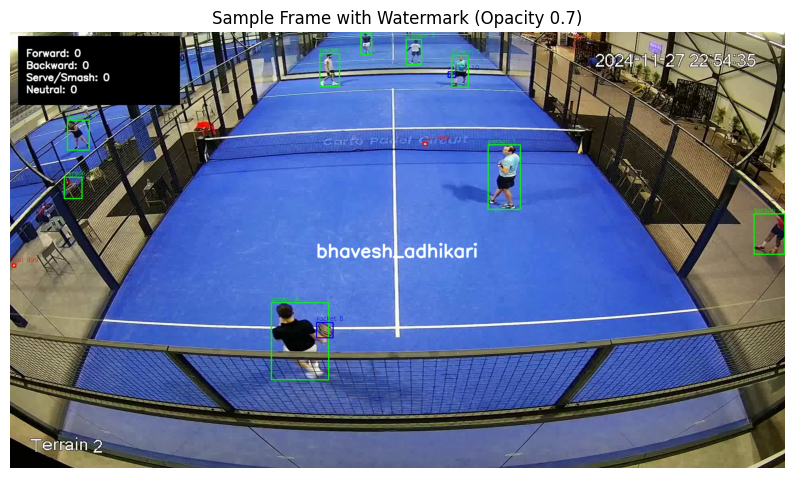

In [93]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Open the video file
cap = cv2.VideoCapture("final_output.mp4")

# Get video properties
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Read a sample frame (e.g., the first frame)
ret, frame = cap.read()

if ret:
    # Create a transparent overlay for the watermark
    overlay = np.zeros((h, w, 3), dtype=np.uint8)

    # Watermark text and properties
    watermark_text = "bhavesh_adhikari"
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1.5
    font_thickness = 3
    text_color = (255, 255, 255) # White color
    outline_color = (0, 0, 0) # Black outline for better visibility
    alpha = 0.7 # Opacity level for the watermark

    # Get text size to center it
    (text_width, text_height), baseline = cv2.getTextSize(watermark_text, font, font_scale, font_thickness)

    # Calculate position for the center
    text_x = int((w - text_width) / 2)
    text_y = int((h + text_height) / 2)

    # Draw black outline on the overlay
    cv2.putText(overlay, watermark_text, (text_x + 2, text_y + 2), font, font_scale, outline_color, font_thickness + 2, cv2.LINE_AA)
    # Draw white text on the overlay
    cv2.putText(overlay, watermark_text, (text_x, text_y), font, font_scale, text_color, font_thickness, cv2.LINE_AA)

    # Blend the overlay with the original frame
    watermarked_frame = cv2.addWeighted(frame, 1, overlay, alpha, 0)

    # Display the watermarked frame
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(watermarked_frame, cv2.COLOR_BGR2RGB))
    plt.title("Sample Frame with Watermark (Opacity 0.7)")
    plt.axis("off")
    plt.show()
else:
    print("Could not read frame from final_output.mp4")

cap.release()

In [95]:
import cv2
import numpy as np

# Open the input video file
cap = cv2.VideoCapture("final_output.mp4")

# Get video properties
fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Define the output video writer
out = cv2.VideoWriter(
    "watermarked_final_output.mp4",
    cv2.VideoWriter_fourcc(*"XVID"), # Changed codec to XVID for better compression
    fps,
    (w, h)
)

# Watermark properties (reusing values from the sample frame experiment)
watermark_text = "bhavesh_adhikari"
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 1.5
font_thickness = 3
text_color = (255, 255, 255) # White
outline_color = (0, 0, 0) # Black
alpha = 0.7 # Opacity

# Pre-calculate text size and position once
(text_width, text_height), baseline = cv2.getTextSize(watermark_text, font, font_scale, font_thickness)
text_x = int((w - text_width) / 2)
text_y = int((h + text_height) / 2)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Create a transparent overlay for the watermark on the current frame
    overlay = np.zeros((h, w, 3), dtype=np.uint8)

    # Draw black outline on the overlay
    cv2.putText(overlay, watermark_text, (text_x + 2, text_y + 2), font, font_scale, outline_color, font_thickness + 2, cv2.LINE_AA)
    # Draw white text on the overlay
    cv2.putText(overlay, watermark_text, (text_x, text_y), font, font_scale, text_color, font_thickness, cv2.LINE_AA)

    # Blend the overlay with the original frame
    watermarked_frame = cv2.addWeighted(frame, 1, overlay, alpha, 0)

    # Write the watermarked frame to the output video
    out.write(watermarked_frame)

# Release video capture and writer objects
cap.release()
out.release()

print("Done -> watermarked_final_output.mp4")

Done -> watermarked_final_output.mp4
